
# Loader and Viewer

== Groups & Channels ==
[MOX1 Data] -> Raw IR 300Hz, Elasped Time, Custom ID\Name, Subject Number, File Marker, Error Code, Oxygen Saturation, Heart Rate, Breath Rate, Breath Distention, Pulse Distention, Activity, Core Temperature, Computer Clock, User Notes, P-P Interval

== Channel diagnostics ==
Activity             | len= 121280 | dtype=float64 | time=-(0)
Breath Distention    | len= 121280 | dtype=float64 | time=-(0)
Breath Rate          | len= 121280 | dtype=float64 | time=-(0)
Computer Clock       | len= 121280 | dtype=object | time=-(0)
Core Temperature     | len= 121280 | dtype=float64 | time=-(0)
Custom ID\Name       | len= 121280 | dtype=object | time=-(0)
Elasped Time         | len= 121280 | dtype=float64 | time=-(0)
Error Code           | len= 121280 | dtype=float64 | time=-(0)
File Marker          | len= 121280 | dtype=float64 | time=-(0)
Heart Rate           | len= 121280 | dtype=float64 | time=-(0)
Oxygen Saturation    | len= 121280 | dtype=float64 | time=-(0)
P-P Inte

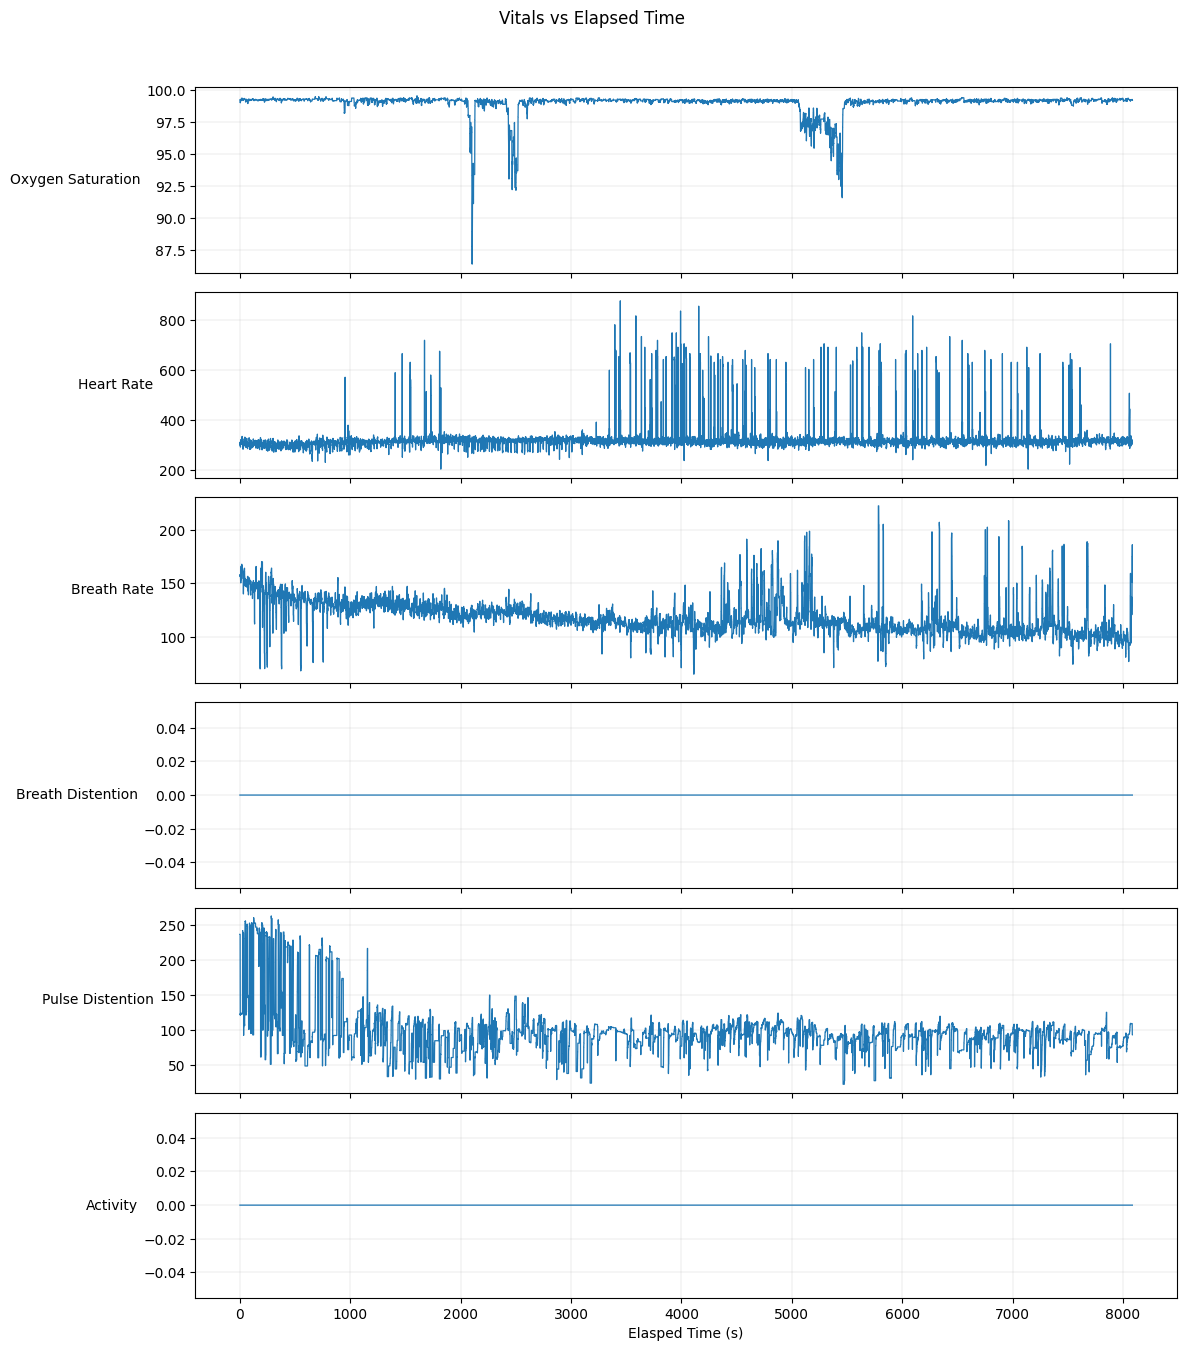

In [4]:
# tdms_view_mox1.py
# pip install nptdms pandas matplotlib

from nptdms import TdmsFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TDMS_PATH = r"C:\Users\GhezziLab\Desktop\100225125451.tdms"

# ---- helpers ----
NUMERIC_KINDS = {"i", "u", "f"}  # int, unsigned, float

def is_numeric_array(a):
    try:
        return a.dtype.kind in NUMERIC_KINDS
    except Exception:
        return False

def get_time_track(ch):
    """Return (t, kind) where t is a time vector (numpy array) and kind is 'relative' or 'absolute' or None."""
    # nptdms provides waveform props for DAQmx-written channels
    dt = ch.properties.get("wf_increment", None)  # seconds per sample
    start_time = ch.properties.get("wf_start_time", None)
    n = len(ch[:])
    if n == 0:
        return None, None
    if dt is not None:
        t_rel = np.arange(n, dtype=float) * float(dt)
        # If absolute start_time exists, you could do: np.array(start_time + np.arange(n)*dt, dtype='datetime64[ns]')
        return t_rel, "relative"
    return None, None  # unknown timing

def summarize(tdms):
    print("== Groups & Channels ==")
    for g in tdms.groups():
        names = [c.name for c in g.channels()]
        print(f"[{g.name}] -> {', '.join(names)}")

def load_mox1(tdms_path):
    tdms = TdmsFile.read(tdms_path)
    summarize(tdms)

    # Gather channels
    grp = None
    for g in tdms.groups():
        if g.name == "MOX1 Data":
            grp = g
            break
    if grp is None:
        raise RuntimeError("Group 'MOX1 Data' not found. Available: " + ", ".join([g.name for g in tdms.groups()]))

    # Pull arrays (skip non-numeric for plotting; still capture elapsed time even if float)
    chans = {ch.name: ch for ch in grp.channels()}
    arrays = {}
    lens = {}
    timing = {}

    for name, ch in chans.items():
        try:
            y = ch[:]
        except Exception as e:
            print(f"[warn] Failed to read '{name}': {e}")
            continue

        n = len(y) if hasattr(y, "__len__") else 0
        lens[name] = n
        tvec, tkind = get_time_track(ch)
        timing[name] = (tkind, (None if tvec is None else len(tvec)))

        # Save arrays verbatim
        arrays[name] = y

    print("\n== Channel diagnostics ==")
    for name in sorted(arrays.keys()):
        y = arrays[name]
        kind = getattr(y, "dtype", None)
        tkind, tlen = timing[name]
        print(f"{name:20s} | len={lens[name]:7d} | dtype={kind} | time={tkind or '-'}({tlen or 0})")

    return arrays, timing

def plot_mox1(arrays, timing, max_vitals=6):
    # Identify candidates
    names = list(arrays.keys())

    # High-rate waveform (heuristic: name contains '300Hz' or length >> median)
    high_rate_name = None
    # Prefer explicit label if present
    for nm in names:
        if "300Hz" in nm or "Raw IR" in nm:
            high_rate_name = nm
            break
    if high_rate_name is None and names:
        lengths = np.array([len(arrays[nm]) for nm in names])
        if len(lengths) > 0:
            med = np.median(lengths[lengths > 0]) if np.any(lengths > 0) else 0
            if med > 0:
                cand = names[int(np.argmax(lengths))]
                if len(arrays[cand]) >= 10 * med:
                    high_rate_name = cand

    # Elapsed time for slow vitals (note: channel uses the file's spelling: "Elasped Time")
    elapsed_name = None
    for nm in names:
        if nm.lower().strip() == "elasped time":
            elapsed_name = nm
            break

    # 1) Plot high-rate waveform if present
    if high_rate_name is not None and is_numeric_array(arrays[high_rate_name]) and len(arrays[high_rate_name]) > 0:
        y = arrays[high_rate_name]
        tvec, tkind = timing.get(high_rate_name, (None, None))
        if tvec == "relative":
            # rebuild relative time
            # we didn't store the array itself, recompute from wf_increment:
            # find dt again via the channel properties
            # Easiest: infer dt from tkind metadata is not enough; we’ll approximate using dt if available
            pass  # handled below using get_time_track again from a tiny helper

    # Rebuild time tracks (need channel object to re-read props), so quick util:
    def time_for(name):
        # lightweight: rebuild from arrays+timing info is not enough; instead infer from MOX1 properties again
        # but we no longer have channel objects here—so we’ll do relative time only when we can infer dt from timing.
        # Simpler approach: if timing[name][0] == 'relative', we can *plot sample index labeled as seconds* by estimating dt from len/elapsed if 'Elasped Time' aligns. To keep robust, we just use sample index.
        return None

    # --- Plot 1: High-rate waveform (sample index or seconds if we can) ---
    if high_rate_name is not None and is_numeric_array(arrays[high_rate_name]) and len(arrays[high_rate_name]) > 0:
        y = arrays[high_rate_name]
        x = np.arange(len(y))
        plt.figure(figsize=(12, 3))
        plt.plot(x, y, linewidth=0.8)
        plt.title(f"{high_rate_name} (samples)")
        plt.xlabel("sample")
        plt.ylabel(high_rate_name)
        plt.grid(True, linewidth=0.3, alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("[info] No high-rate numeric waveform found to plot.")

    # 2) Stack a few vitals vs elapsed time (if available)
    vitals_candidates = [
        "Oxygen Saturation", "Heart Rate", "Breath Rate",
        "Breath Distention", "Pulse Distention", "Activity",
        "Core Temperature", "P-P Interval", "File Marker"
    ]
    vitals = [nm for nm in vitals_candidates if nm in arrays and is_numeric_array(arrays[nm]) and len(arrays[nm]) > 0]
    vitals = vitals[:max_vitals]

    if elapsed_name and elapsed_name in arrays and is_numeric_array(arrays[elapsed_name]) and len(arrays[elapsed_name]) > 0 and vitals:
        t = np.asarray(arrays[elapsed_name], dtype=float)
        # Ensure t is strictly increasing (some devices repeat last stamp)
        if len(t) > 1 and np.any(np.diff(t) <= 0):
            # Make a monotonic proxy index if needed
            t = np.arange(len(t), dtype=float)

        rows = len(vitals)
        fig, axes = plt.subplots(rows, 1, figsize=(12, 2.2*rows), sharex=True)
        if rows == 1:
            axes = [axes]
        for ax, name in zip(axes, vitals):
            y = np.asarray(arrays[name], dtype=float)
            n = min(len(t), len(y))
            ax.plot(t[:n], y[:n], linewidth=0.9)
            ax.set_ylabel(name, rotation=0, ha="right", va="center")
            ax.grid(True, linewidth=0.3, alpha=0.6)
        axes[-1].set_xlabel(f"{elapsed_name} (s)")
        fig.suptitle("Vitals vs Elapsed Time", y=1.02, fontsize=12)
        fig.tight_layout()
        plt.show()
    else:
        if not vitals:
            print("[info] No numeric vitals found to plot.")
        if not elapsed_name or len(arrays.get(elapsed_name, [])) == 0:
            print("[info] No usable 'Elasped Time' channel; skipping stacked vitals plot.")

if __name__ == "__main__":
    arrays, timing = load_mox1(TDMS_PATH)
    plot_mox1(arrays, timing, max_vitals=6)


# Excel Exporter

In [5]:
# tdms_to_excel_mox1.py
# Export MOX1 TDMS to Excel with vitals and high-rate waveform
# pip install nptdms pandas openpyxl

from nptdms import TdmsFile
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Any

TDMS_PATH = r"C:\Users\GhezziLab\Desktop\100225125451.tdms"
OUT_XLSX = str(Path(TDMS_PATH).with_suffix("")) + "_export.xlsx"

EXCEL_MAX_ROWS = 1_048_576  # Excel hard limit per sheet

NUMERIC_KINDS = {"i", "u", "f"}  # int, unsigned, float

def is_numeric_array(arr) -> bool:
    try:
        return hasattr(arr, "dtype") and (arr.dtype.kind in NUMERIC_KINDS)
    except Exception:
        return False

def read_mox1(tdms_path: str):
    tdms = TdmsFile.read(tdms_path)
    grp = None
    for g in tdms.groups():
        if g.name == "MOX1 Data":
            grp = g
            break
    if grp is None:
        raise RuntimeError("Group 'MOX1 Data' not found.")

    channels = {ch.name: ch for ch in grp.channels()}

    arrays: Dict[str, Any] = {}
    dtypes: Dict[str, Any] = {}
    lengths: Dict[str, int] = {}
    props: Dict[str, Dict[str, Any]] = {}

    for name, ch in channels.items():
        try:
            y = ch[:]
        except Exception as e:
            print(f"[warn] Could not read channel '{name}': {e}")
            continue
        arrays[name] = y
        dtypes[name] = getattr(y, "dtype", None)
        lengths[name] = len(y) if hasattr(y, "__len__") else 0
        # capture properties as simple dict (convert non-serializable to str)
        pdict = {}
        for k, v in ch.properties.items():
            try:
                _ = str(v) if isinstance(v, (bytes, bytearray)) else v
                pdict[k] = v
            except Exception:
                pdict[k] = repr(v)
        props[name] = pdict

    return arrays, dtypes, lengths, props

def build_vitals_dataframe(arrays: Dict[str, Any]) -> pd.DataFrame:
    # device uses "Elasped Time" spelling—preserve it
    elapsed_key = None
    for nm in arrays.keys():
        if nm.lower().strip() == "elasped time":
            elapsed_key = nm
            break

    # Candidate vitals (only numeric & non-empty included)
    vitals_candidates = [
        "Oxygen Saturation", "Heart Rate", "Breath Rate",
        "Breath Distention", "Pulse Distention", "Activity",
        "Core Temperature", "P-P Interval", "File Marker",
        "Error Code", "Subject Number"
    ]

    if elapsed_key is None or len(arrays.get(elapsed_key, [])) == 0 or not is_numeric_array(arrays[elapsed_key]):
        # No elapsed time; write vitals using a sample index instead
        cols = {}
        max_len = 0
        for nm in vitals_candidates:
            if nm in arrays and is_numeric_array(arrays[nm]) and len(arrays[nm]) > 0:
                cols[nm] = np.asarray(arrays[nm]).astype(float)
                max_len = max(max_len, len(cols[nm]))
        if not cols:
            return pd.DataFrame()  # nothing usable
        # pad shorter series with NaN to align lengths
        for nm, y in cols.items():
            if len(y) < max_len:
                pad = np.full(max_len - len(y), np.nan)
                cols[nm] = np.concatenate([y, pad])
        df = pd.DataFrame(cols)
        df.insert(0, "sample", np.arange(len(df), dtype=float))
        return df

    # With elapsed time: align vitals by min length with elapsed
    t = np.asarray(arrays[elapsed_key], dtype=float)
    cols = {"Elapsed Time (s)": t}
    min_n = len(t)
    for nm in vitals_candidates:
        if nm in arrays and is_numeric_array(arrays[nm]) and len(arrays[nm]) > 0:
            y = np.asarray(arrays[nm], dtype=float)
            n = min(len(y), len(t))
            cols[nm] = y[:n]
            min_n = min(min_n, n)
    # truncate all to shared length
    for k in list(cols.keys()):
        cols[k] = cols[k][:min_n]
    return pd.DataFrame(cols)

def write_dataframe_in_chunks(writer, df: pd.DataFrame, base_sheet: str):
    """
    Write df to one or more sheets if it exceeds EXCEL_MAX_ROWS.
    """
    n = len(df)
    if n <= EXCEL_MAX_ROWS:
        df.to_excel(writer, sheet_name=base_sheet, index=False)
        return [base_sheet]

    sheet_names = []
    start = 0
    part = 1
    while start < n:
        end = min(start + EXCEL_MAX_ROWS, n)
        sheet = f"{base_sheet}_{part}"
        df.iloc[start:end].to_excel(writer, sheet_name=sheet, index=False)
        sheet_names.append(sheet)
        start = end
        part += 1
    return sheet_names

def main():
    arrays, dtypes, lengths, props = read_mox1(TDMS_PATH)

    # Build diagnostics
    diag_rows = []
    for nm in sorted(arrays.keys()):
        arr = arrays[nm]
        diag_rows.append({
            "Channel": nm,
            "Length": lengths.get(nm, 0),
            "Dtype": str(dtypes.get(nm, "")),
            "IsNumeric": bool(is_numeric_array(arr)),
            "NonEmpty": bool(lengths.get(nm, 0) > 0),
        })
    df_diag = pd.DataFrame(diag_rows)

    # Build properties table (flatten per-channel)
    prop_rows = []
    for nm, pdict in props.items():
        if not pdict:
            prop_rows.append({"Channel": nm, "Property": "(none)", "Value": ""})
        else:
            for k, v in pdict.items():
                # Ensure excel-safe by stringifying uncommon objects
                if not isinstance(v, (int, float, str, np.integer, np.floating)):
                    v = str(v)
                prop_rows.append({"Channel": nm, "Property": k, "Value": v})
    df_props = pd.DataFrame(prop_rows)

    # Identify the high-rate waveform
    hr_name = None
    for nm in arrays.keys():
        if "300Hz" in nm or "Raw IR" in nm:
            hr_name = nm
            break
    if hr_name is None and arrays:
        # heuristic: pick the longest numeric channel
        candidates = [(nm, lengths[nm]) for nm in arrays.keys() if is_numeric_array(arrays[nm])]
        if candidates:
            hr_name = max(candidates, key=lambda x: x[1])[0]

    # Build waveform DataFrame
    df_wave = pd.DataFrame()
    if hr_name and is_numeric_array(arrays[hr_name]) and lengths.get(hr_name, 0) > 0:
        y = np.asarray(arrays[hr_name], dtype=float)
        # Try to recover dt if present
        dt = None
        try:
            wf_inc = props.get(hr_name, {}).get("wf_increment", None)
            dt = float(wf_inc) if wf_inc is not None else None
        except Exception:
            dt = None
        if dt is not None:
            t = np.arange(len(y), dtype=float) * dt
            df_wave = pd.DataFrame({"time_s": t, hr_name: y})
        else:
            df_wave = pd.DataFrame({"sample": np.arange(len(y), dtype=float), hr_name: y})

    # Build vitals DataFrame
    df_vitals = build_vitals_dataframe(arrays)

    # Write Excel
    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        # Diagnostics & properties first
        df_diag.to_excel(writer, sheet_name="Channel_Diagnostics", index=False)
        if not df_props.empty:
            df_props.to_excel(writer, sheet_name="Properties", index=False)

        # Vitals
        if not df_vitals.empty:
            # Keep columns ordered (Elapsed Time first if present)
            df_vitals.to_excel(writer, sheet_name="Vitals", index=False)

        # High-rate waveform (split across sheets if too long)
        if not df_wave.empty:
            written = write_dataframe_in_chunks(writer, df_wave, base_sheet="Raw_IR_300Hz")
            # Record a small index of chunk sheets
            idx_df = pd.DataFrame({"Raw_IR_300Hz_Sheets": written})
            idx_df.to_excel(writer, sheet_name="Waveform_Index", index=False)

    print(f"[ok] Wrote Excel to: {OUT_XLSX}")
    print("Sheets included:")
    print(" - Channel_Diagnostics")
    if not df_props.empty:
        print(" - Properties")
    if not df_vitals.empty:
        print(" - Vitals")
    if not df_wave.empty:
        print(" - Waveform_Index")
        # chunk sheet names already printed into Waveform_Index

if __name__ == "__main__":
    main()


[ok] Wrote Excel to: C:\Users\GhezziLab\Desktop\100225125451_export.xlsx
Sheets included:
 - Channel_Diagnostics
 - Properties
 - Vitals
